best k: 14
customer purchase prediction
-----------------------------------
accuracy: 0.675
-----------------------------------
               precision    recall  f1-score   support

not purchased       0.58      0.47      0.52        15
    purchased       0.71      0.80      0.75        25

     accuracy                           0.68        40
    macro avg       0.65      0.63      0.64        40
 weighted avg       0.67      0.68      0.67        40



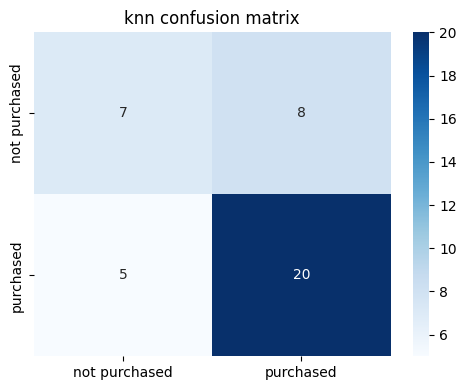

new customer: will purchase!
confidence: 57.1 %


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [5]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

np.random.seed(42)
n = 200

data = {
    "age":            np.random.randint(18, 65, n),
    "income":         np.random.randint(15000, 120000, n),
    "time_on_site":   np.random.randint(1, 60, n),
    "pages_visited":  np.random.randint(1, 20, n),
    "purchased":      np.random.choice([0, 1], n, p=[0.45, 0.55])
}

df = pd.DataFrame(data)

x = df.drop("purchased", axis=1)
y = df["purchased"]

scaler = StandardScaler()
x_scaled = scaler.fit_transform(x)

x_train, x_test, y_train, y_test = train_test_split(
    x_scaled, y, test_size=0.2, random_state=42
)

test_scores = []
for k in range(1, 21):
    m = KNeighborsClassifier(n_neighbors=k)
    m.fit(x_train, y_train)
    test_scores.append(m.score(x_test, y_test))

best_k = test_scores.index(max(test_scores)) + 1
print("best k:", best_k)

model = KNeighborsClassifier(n_neighbors=best_k)
model.fit(x_train, y_train)
y_pred = model.predict(x_test)

print("customer purchase prediction")
print("-" * 35)
print("accuracy:", round(accuracy_score(y_test, y_pred), 3))
print("-" * 35)
print(classification_report(y_test, y_pred,
      target_names=["not purchased", "purchased"]))

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["not purchased", "purchased"],
            yticklabels=["not purchased", "purchased"])
plt.title("knn confusion matrix")
plt.tight_layout()
plt.show()

new_customer = scaler.transform([[28, 55000, 15, 8]])
result = model.predict(new_customer)
prob = model.predict_proba(new_customer)
print("new customer:",
      "will purchase!" if result[0] == 1 else "wont purchase")
print("confidence:", round(max(prob[0]) * 100, 1), "%")